In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

data = []
labels = []

emotion_map = {
    'AN':0, 'DI':1, 'FE':2,
    'HA':3, 'SA':4, 'SU':5, 'NE':6
}


In [3]:

dataset_path = "/kaggle/input/datasets/navneet0094/jafee-data/jaffe"

for img_name in os.listdir(dataset_path):

    img_path = os.path.join(dataset_path, img_name)

    try:
        # grayscale
        img = Image.open(img_path).convert('L') # luminised only if P -> rgb paltetised

        # resize to 128x128
        img = img.resize((128,128))

        img = np.array(img)

        emotion = img_name.split('.')[1][:2]
        label = emotion_map[emotion]

        data.append(img)
        labels.append(label)

    except Exception as e:
        print("Error:", img_name)

data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels:", np.unique(labels))

Data shape: (213, 128, 128)
Labels: [0 1 2 3 4 5 6]


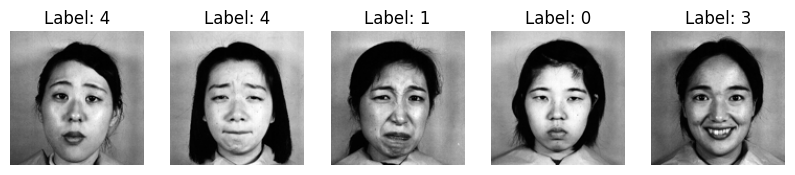

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(data[i], cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')

plt.show()

In [5]:
# HOG
from skimage.feature import hog

X_hog = []

for img in data:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )
    X_hog.append(features)

X_hog = np.array(X_hog)

print("HOG feature shape:", X_hog.shape)

HOG feature shape: (213, 8100)


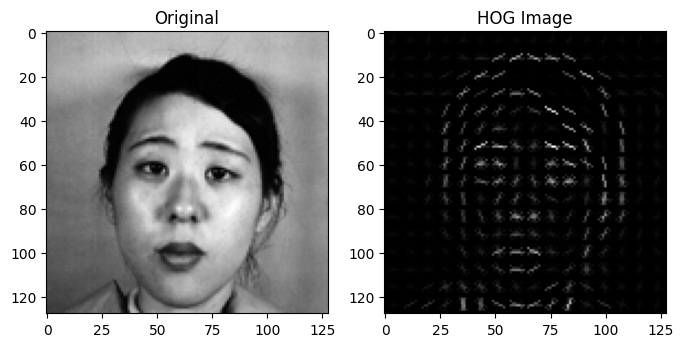

In [6]:
# HOG vis
sample_img = data[0]

features, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample_img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Image")

plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report



In [8]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess


# Load pretrained model (feature extractor)
mobilenet = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

# VGG
vgg = VGG16(weights='imagenet', include_top=False, pooling='avg')

2026-06-17 14:49:55.756833: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781707796.154084      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781707796.264229      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781707797.225965      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781707797.226081      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781707797.226087      16 computation_placer.cc:177] computation placer alr

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
import cv2
import numpy as np

def extract_cnn_features(images, model):
    features = []
    
    for img in images:
        img = cv2.resize(img, (224,224))
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = preprocess_input(img)
    
        img = np.expand_dims(img, axis=0)
        
        feat = model.predict(img, verbose=0)
        features.append(feat.flatten())
    
    return np.array(features)

In [10]:
def extract_vgg_features(images, model):
    features = []
    
    for img in images:
        img = cv2.resize(img, (224,224))
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = vgg_preprocess(img)
        
        img = np.expand_dims(img, axis=0)
        feat = model.predict(img, verbose=0)
        
        features.append(feat.flatten())
    
    return np.array(features)

In [11]:
# MobileNet features
X_cnn = extract_cnn_features(data, mobilenet)

print("Mobilenet feature shape:", X_cnn.shape)

Mobilenet feature shape: (213, 1280)


In [12]:
# VGG features
X_vgg = extract_vgg_features(data, vgg)

print("VGG feature shape:", X_vgg.shape)

VGG feature shape: (213, 512)


In [13]:
from sklearn.preprocessing import StandardScaler

# Separate scalers
hog_scaler = StandardScaler()
cnn_scaler = StandardScaler()
vgg_scaler = StandardScaler()

# Normalize features
X_hog_scaled = hog_scaler.fit_transform(X_hog)

X_cnn_scaled = cnn_scaler.fit_transform(X_cnn)

X_vgg_scaled = vgg_scaler.fit_transform(X_vgg)

print("HOG scaled:", X_hog_scaled.shape)
print("CNN scaled:", X_cnn_scaled.shape)
print("VGG scaled:", X_vgg_scaled.shape)

HOG scaled: (213, 8100)
CNN scaled: (213, 1280)
VGG scaled: (213, 512)


## Weighted Fusion

In [14]:
# Features = αH(Hog)​+αM(mobilenet)​+αV(vgg)
# αH​+αM​+αV​=1

# Feature	Attention
# HOG	0.6
# MobileNet	0.3
# VGG	0.1

# Feature	Attention
# HOG	0.7
# MobileNet	0.2
# VGG	0.1

# Feature	Attention
# HOG	0.5
# MobileNet	0.4
# VGG	0.1

# Feature	Attention
# HOG	0.35
# MobileNet	0.34
# VGG	0.34

# Feature	Attention
# HOG	0.35
# MobileNet	0.35
# VGG	0.3

In [15]:
hog_weight =0.6
mobilenet_weight = 0.3
vgg_weight = 0.1

In [16]:
X_hog_weighted = X_hog_scaled * hog_weight

X_mobilenet_weighted = X_cnn_scaled * mobilenet_weight

X_vgg_weighted = X_vgg_scaled * vgg_weight

In [17]:
X_weighted_fusion = np.concatenate([
    X_hog_weighted,
    X_mobilenet_weighted,
    X_vgg_weighted
], axis=1)

print("Weighted Fusion Shape:",
      X_weighted_fusion.shape)

Weighted Fusion Shape: (213, 9892)


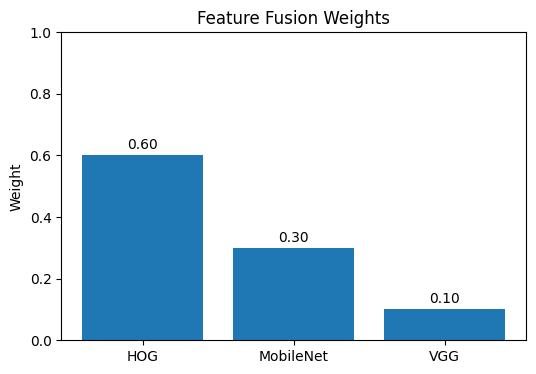

In [18]:
# WEIGHT VISUALIZATION

features = ['HOG', 'MobileNet', 'VGG']

weights = [
    hog_weight,
    mobilenet_weight,
    vgg_weight
]

plt.figure(figsize=(6,4))

bars = plt.bar(features, weights)

plt.ylim(0,1)

plt.title("Feature Fusion Weights")

plt.ylabel("Weight")

# values on top
for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.02,
        f"{yval:.2f}",
        ha='center'
    )

plt.show()

In [19]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

model = Pipeline([

    ('svm', SVC(
        kernel='linear',
        probability=True
    ))
])

In [20]:
from sklearn.model_selection import cross_val_predict

y_probs = cross_val_predict(
    model,
    X_weighted_fusion,
    labels,
    cv=10,
    method='predict_proba'
)

In [21]:
y_probs

array([[0.01547287, 0.02406013, 0.14618336, ..., 0.7063634 , 0.02595837,
        0.04404775],
       [0.00613932, 0.0189217 , 0.07659644, ..., 0.85993637, 0.00855204,
        0.01404694],
       [0.0695583 , 0.61613557, 0.20502168, ..., 0.0562281 , 0.00634446,
        0.00591527],
       ...,
       [0.0376757 , 0.11555695, 0.09163844, ..., 0.42285715, 0.05493599,
        0.26300842],
       [0.00664587, 0.04706106, 0.04360942, ..., 0.02723842, 0.02369554,
        0.02395759],
       [0.04436051, 0.04640966, 0.05057344, ..., 0.10088176, 0.0618294 ,
        0.6127051 ]], shape=(213, 7))

In [22]:
y_pred = np.argmax(y_probs, axis=1)

confidence_scores = np.max(
    y_probs,
    axis=1
)

In [23]:
from sklearn.metrics import accuracy_score

overall_acc_1 = accuracy_score(labels, y_pred)
print("Weighted Fusion Accuracy:",round(overall_acc_1,4))

Weighted Fusion Accuracy: 0.8873


In [24]:
# CLASSIFICATION REPORT

from sklearn.metrics import classification_report

emotion_names = [
    'anger',
    'disgust',
    'fear',
    'happy',
    'sadness',
    'surprise',
    'neutral'
]

print(

    classification_report(
        labels,
        y_pred,
        target_names=emotion_names
    )

)

              precision    recall  f1-score   support

       anger       0.96      0.87      0.91        30
     disgust       0.81      0.90      0.85        29
        fear       0.84      0.81      0.83        32
       happy       0.91      1.00      0.95        31
     sadness       0.81      0.81      0.81        31
    surprise       0.97      0.93      0.95        30
     neutral       0.93      0.90      0.92        30

    accuracy                           0.89       213
   macro avg       0.89      0.89      0.89       213
weighted avg       0.89      0.89      0.89       213



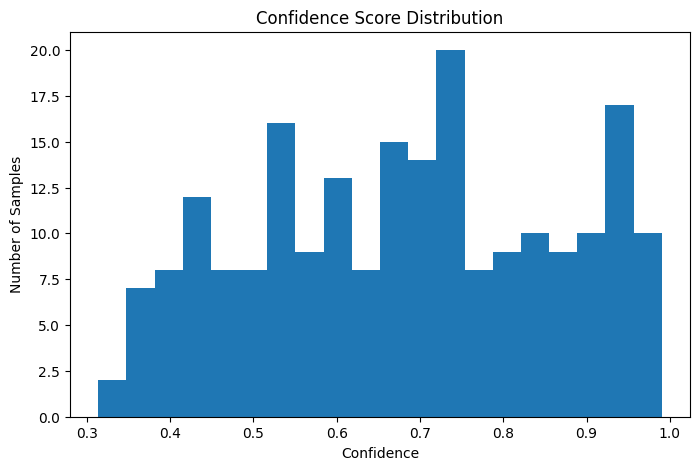

In [25]:
# CONFIDENCE DISTRIBUTION

plt.figure(figsize=(8,5))

plt.hist(
    confidence_scores,
    bins=20
)

plt.title(
    "Confidence Score Distribution"
)

plt.xlabel("Confidence")

plt.ylabel("Number of Samples")

plt.show()

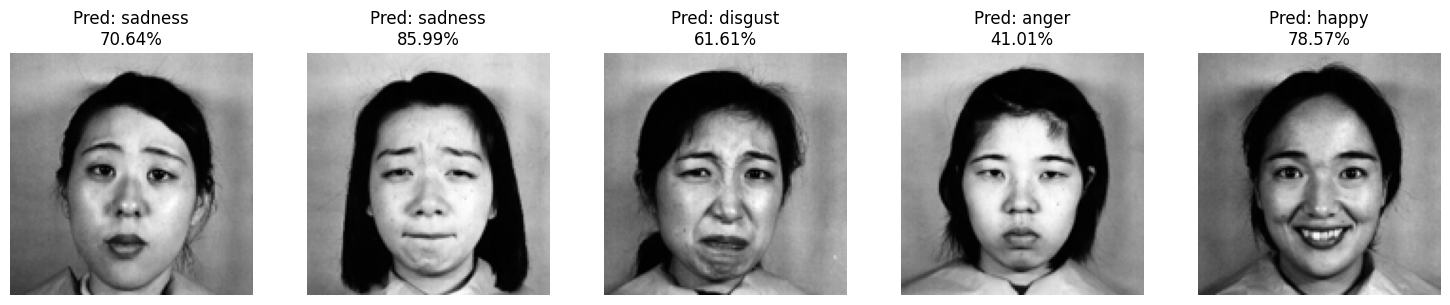

In [26]:
# SAMPLE PREDICTIONS IN SINGLE FIGURE

plt.figure(figsize=(15,3))

for i in range(5):

    plt.subplot(1, 5, i+1)

    plt.imshow(data[i], cmap='gray')

    plt.title(
        f"Pred: {emotion_names[y_pred[i]]}\n"
        f"{confidence_scores[i]*100:.2f}%"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

In [27]:
# Rejecting Uncertain samples

In [28]:
thresholds = [0.4, 0.5, 0.6, 0.7, 0.8]

In [29]:
thresholds = [0.4, 0.5, 0.6, 0.7, 0.8]

for t in thresholds:

    accepted = confidence_scores >= t

    accepted_accuracy = np.mean(
        y_pred[accepted] == labels[accepted]
    )

    print(f"\nThreshold: {t}")

    print("Accepted:",
          np.sum(accepted))

    print("Rejected:",
          np.sum(~accepted))

    print("Accuracy on accepted samples:",
          accepted_accuracy)


Threshold: 0.4
Accepted: 202
Rejected: 11
Accuracy on accepted samples: 0.9108910891089109

Threshold: 0.5
Accepted: 172
Rejected: 41
Accuracy on accepted samples: 0.9593023255813954

Threshold: 0.6
Accepted: 136
Rejected: 77
Accuracy on accepted samples: 0.9779411764705882

Threshold: 0.7
Accepted: 100
Rejected: 113
Accuracy on accepted samples: 0.98

Threshold: 0.8
Accepted: 61
Rejected: 152
Accuracy on accepted samples: 0.9836065573770492


In [30]:
threshold = 0.6

accepted = confidence_scores >= threshold

rejected = confidence_scores < threshold

print("Accepted Samples:",
      np.sum(accepted))

print("Rejected Samples:",
      np.sum(rejected))

Accepted Samples: 136
Rejected Samples: 77


In [31]:
filtered_acc_1 = accuracy_score(
    labels[accepted],
    y_pred[accepted]
)

print(
    "Accuracy After Rejecting "
    "Uncertain Samples:",
    filtered_acc_1
)

Accuracy After Rejecting Uncertain Samples: 0.9779411764705882


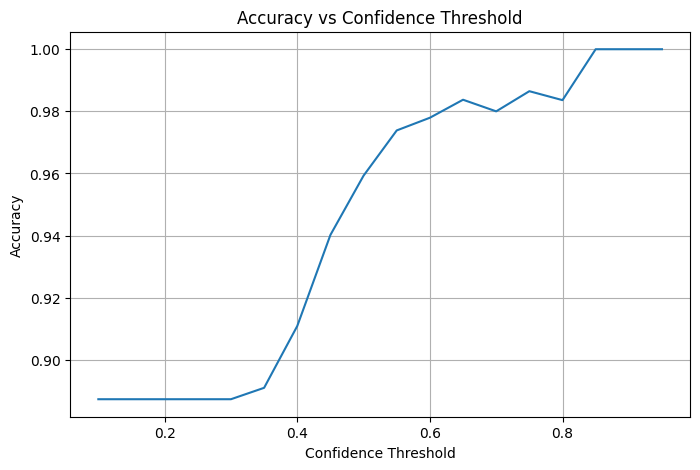

In [32]:
thresholds = np.arange(0.1, 1.0, 0.05)

accuracies = []

for t in thresholds:

    mask = confidence_scores >= t

    if np.sum(mask) > 0:

        acc = accuracy_score(
            labels[mask],
            y_pred[mask]
        )

        accuracies.append(acc)

    else:
        accuracies.append(0)

plt.figure(figsize=(8,5))

plt.plot(thresholds, accuracies)

plt.xlabel("Confidence Threshold")

plt.ylabel("Accuracy")

plt.title(
    "Accuracy vs Confidence Threshold"
)

plt.grid()

plt.show()

In [33]:
# SECOND WEIGHT 
hog_weight_2 = 0.7
cnn_weight_2 = 0.2
vgg_weight_2 = 0.1

In [34]:
# APPLY NEW WEIGHTS

X_hog_weighted_2 = (
    X_hog_scaled * hog_weight_2
)

X_cnn_weighted_2 = (
    X_cnn_scaled * cnn_weight_2
)

X_vgg_weighted_2 = (
    X_vgg_scaled * vgg_weight_2
)

In [35]:
# SECOND WEIGHTED FUSION

X_weighted_fusion_2 = np.concatenate([

    X_hog_weighted_2,

    X_cnn_weighted_2,

    X_vgg_weighted_2

], axis=1)

print(
    "Fusion Shape:",
    X_weighted_fusion_2.shape
)

Fusion Shape: (213, 9892)


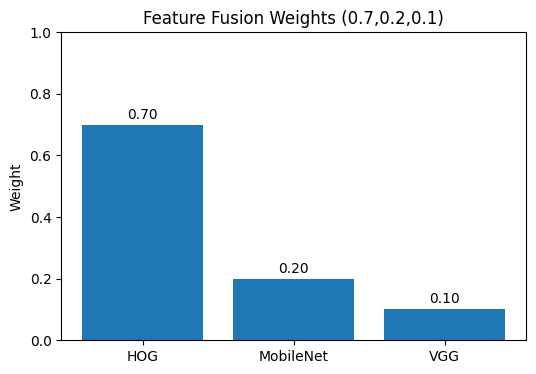

In [36]:
# VISUALIZE WEIGHTS

features = [
    'HOG',
    'MobileNet',
    'VGG'
]

weights_2 = [
    hog_weight_2,
    cnn_weight_2,
    vgg_weight_2
]

plt.figure(figsize=(6,4))

bars = plt.bar(
    features,
    weights_2
)

plt.ylim(0,1)

plt.title(
    "Feature Fusion Weights (0.7,0.2,0.1)"
)

plt.ylabel("Weight")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.02,
        f"{yval:.2f}",
        ha='center'
    )

plt.show()

In [37]:
# CONFIDENCE-AWARE SVM

model_2 = Pipeline([

    ('svm', SVC(
        kernel='linear',
        probability=True
    ))
])

In [38]:
# PREDICT PROBABILITIES

y_probs_2 = cross_val_predict(

    model_2,

    X_weighted_fusion_2,

    labels,

    cv=10,

    method='predict_proba'
)

In [39]:
# FINAL PREDICTIONS

y_pred_2 = np.argmax(
    y_probs_2,
    axis=1
)

confidence_scores_2 = np.max(
    y_probs_2,
    axis=1
)

In [40]:
# ACCURACY

overall_acc_2 = accuracy_score(
    labels,
    y_pred_2
)

print(
    "Weighted Fusion Accuracy:",
    round(overall_acc_2,4)
)

Weighted Fusion Accuracy: 0.8967


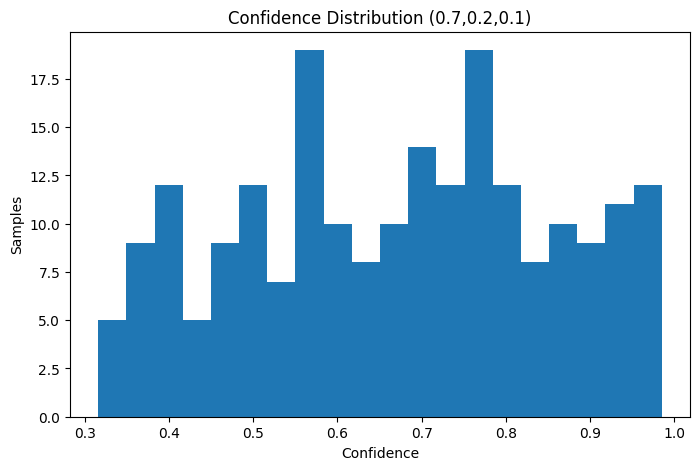

In [41]:
# CONFIDENCE DISTRIBUTION

plt.figure(figsize=(8,5))

plt.hist(
    confidence_scores_2,
    bins=20
)

plt.title(
    "Confidence Distribution (0.7,0.2,0.1)"
)

plt.xlabel("Confidence")

plt.ylabel("Samples")

plt.show()

In [42]:
# CONFIDENCE THRESHOLD ANALYSIS
thresholds = [0.4, 0.5, 0.6, 0.7, 0.8]

for t in thresholds:

    # Accepted
    accepted_2 = confidence_scores_2 >= t
    rejected_2 = confidence_scores_2 < t

    # Accepted accuracy
    accepted_accuracy_2 = np.mean(
        y_pred_2[accepted_2] == labels[accepted_2]
    )

    print(f"\nThreshold: {t}")

    print("Accepted:",np.sum(accepted_2))

    print("Rejected:",np.sum(rejected_2))

    print("Accepted Accuracy:",accepted_accuracy_2)

  


Threshold: 0.4
Accepted: 196
Rejected: 17
Accepted Accuracy: 0.9132653061224489

Threshold: 0.5
Accepted: 168
Rejected: 45
Accepted Accuracy: 0.9583333333333334

Threshold: 0.6
Accepted: 132
Rejected: 81
Accepted Accuracy: 0.9848484848484849

Threshold: 0.7
Accepted: 100
Rejected: 113
Accepted Accuracy: 0.98

Threshold: 0.8
Accepted: 57
Rejected: 156
Accepted Accuracy: 1.0


In [43]:
# REJECT UNCERTAIN SAMPLES

threshold = 0.6

accepted_2 = (
    confidence_scores_2 >= threshold
)

rejected_2 = (
    confidence_scores_2 < threshold
)

print(
    "Accepted:",
    np.sum(accepted_2)
)

print(
    "Rejected:",
    np.sum(rejected_2)
)

Accepted: 132
Rejected: 81


In [44]:
# FILTERED ACCURACY

filtered_acc_2 = accuracy_score(labels[accepted_2],y_pred_2[accepted_2])

print("Accuracy After Rejection:",round(filtered_acc_2,4))

Accuracy After Rejection: 0.9848


In [45]:
# COMPARISON TABLE

import pandas as pd

comparison_df = pd.DataFrame({

    'Fusion Setting': ['0.6 / 0.3 / 0.1','0.7 / 0.2 / 0.1'],

    'Overall Accuracy': [overall_acc_1,overall_acc_2],

    'Filtered Accuracy': [filtered_acc_1,filtered_acc_2],

    'Rejected Samples': [np.sum(rejected),np.sum(rejected_2)]

})

print(comparison_df)

    Fusion Setting  Overall Accuracy  Filtered Accuracy  Rejected Samples
0  0.6 / 0.3 / 0.1          0.887324           0.977941                77
1  0.7 / 0.2 / 0.1          0.896714           0.984848                81


In [46]:
# LEARNED WEIGHTS FROM INDIVIDUAL ACCURACIES

hog_acc = 0.89
mobilenet_acc = 0.86
vgg_acc = 0.74

total = hog_acc + mobilenet_acc + vgg_acc

hog_weight_learned = hog_acc / total
mobilenet_weight_learned = mobilenet_acc / total
vgg_weight_learned = vgg_acc / total

print("HOG Weight:", round(hog_weight_learned,4))
print("MobileNet Weight:", round(mobilenet_weight_learned,4))
print("VGG Weight:", round(vgg_weight_learned,4))

HOG Weight: 0.3574
MobileNet Weight: 0.3454
VGG Weight: 0.2972


In [47]:
# APPLY LEARNED WEIGHTS

X_hog_learned_weighted = (X_hog_scaled * hog_weight_learned)

X_mobilenet_learned_weighted = (X_cnn_scaled * mobilenet_weight_learned)

X_vgg_learned_weighted = (X_vgg_scaled * vgg_weight_learned)

In [48]:
# LEARNED WEIGHTED FUSION

X_learned_weighted_fusion = np.concatenate([X_hog_learned_weighted,X_mobilenet_learned_weighted,X_vgg_learned_weighted], axis=1)

print("Fusion Shape:",X_learned_weighted_fusion.shape)

Fusion Shape: (213, 9892)


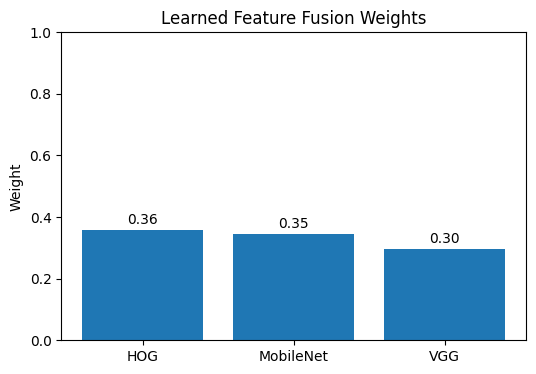

In [49]:
# =========================================
# VISUALIZE LEARNED WEIGHTS
# =========================================

features = ['HOG', 'MobileNet', 'VGG']

weights = [
    hog_weight_learned,
    mobilenet_weight_learned,
    vgg_weight_learned
]

plt.figure(figsize=(6,4))

bars = plt.bar(features, weights)

plt.ylim(0,1)

plt.title("Learned Feature Fusion Weights")

plt.ylabel("Weight")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.02,
        f"{yval:.2f}",
        ha='center'
    )

plt.show()

In [50]:
# CONFIDENCE-AWARE SVM

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

model_learned = Pipeline([

    ('svm', SVC(
        kernel='linear',
        probability=True
    ))
])

In [51]:
# PREDICT PROBABILITIES

from sklearn.model_selection import cross_val_predict

y_probs_learned = cross_val_predict(

    model_learned,

    X_learned_weighted_fusion,

    labels,

    cv=10,

    method='predict_proba'
)

In [52]:
# FINAL PREDICTIONS

y_pred_learned = np.argmax(
    y_probs_learned,
    axis=1
)

confidence_scores_learned = np.max(
    y_probs_learned,
    axis=1
)

In [53]:
# OVERALL ACCURACY

from sklearn.metrics import accuracy_score

overall_acc_learned = accuracy_score(
    labels,
    y_pred_learned
)

print(
    "Learned Weighted Fusion Accuracy:",
    round(overall_acc_learned,4)
)

Learned Weighted Fusion Accuracy: 0.9155


In [54]:
# CLASSIFICATION REPORT
from sklearn.metrics import classification_report

print(

    classification_report(
        labels,
        y_pred_learned,
        target_names=emotion_names
    )

)

              precision    recall  f1-score   support

       anger       1.00      0.93      0.97        30
     disgust       0.90      0.90      0.90        29
        fear       0.88      0.88      0.88        32
       happy       0.91      1.00      0.95        31
     sadness       0.84      0.87      0.86        31
    surprise       0.96      0.90      0.93        30
     neutral       0.93      0.93      0.93        30

    accuracy                           0.92       213
   macro avg       0.92      0.92      0.92       213
weighted avg       0.92      0.92      0.92       213



In [55]:
# CONFIDENCE THRESHOLD ANALYSIS

thresholds = [0.4, 0.5, 0.6, 0.7, 0.8]

for t in thresholds:

    accepted_learned = (
        confidence_scores_learned >= t
    )

    rejected_learned = (
        confidence_scores_learned < t
    )

    accepted_accuracy_learned = np.mean(

        y_pred_learned[accepted_learned]

        ==

        labels[accepted_learned]
    )

    print(f"\nThreshold: {t}")

    print(
        "Accepted:",
        np.sum(accepted_learned)
    )

    print(
        "Rejected:",
        np.sum(rejected_learned)
    )

    print(
        "Accepted Accuracy:",
        accepted_accuracy_learned
    )


Threshold: 0.4
Accepted: 203
Rejected: 10
Accepted Accuracy: 0.9310344827586207

Threshold: 0.5
Accepted: 180
Rejected: 33
Accepted Accuracy: 0.9444444444444444

Threshold: 0.6
Accepted: 146
Rejected: 67
Accepted Accuracy: 0.9794520547945206

Threshold: 0.7
Accepted: 115
Rejected: 98
Accepted Accuracy: 0.991304347826087

Threshold: 0.8
Accepted: 75
Rejected: 138
Accepted Accuracy: 0.9866666666666667


In [56]:
# FILTERED ACCURACY

threshold = 0.6

accepted_learned = (confidence_scores_learned >= threshold)

filtered_acc_learned = accuracy_score(labels[accepted_learned],y_pred_learned[accepted_learned])

print("Filtered Accuracy:",round(filtered_acc_learned,4))

Filtered Accuracy: 0.9795


In [57]:
# FINAL COMPARISON TABLE

comparison_df = pd.DataFrame({

    'Fusion Method': ['Manual (0.6,0.3,0.1)','Manual (0.7,0.2,0.1)','Learned Weights'],

    'Overall Accuracy': [
        overall_acc_1,
        overall_acc_2,
        overall_acc_learned
    ],
    'Filtered Accuracy': [
        filtered_acc_1,
        filtered_acc_2,
        filtered_acc_learned
    ]
})
print(comparison_df)

          Fusion Method  Overall Accuracy  Filtered Accuracy
0  Manual (0.6,0.3,0.1)          0.887324           0.977941
1  Manual (0.7,0.2,0.1)          0.896714           0.984848
2       Learned Weights          0.915493           0.979452


In [58]:
print(f"Weighted Fusion Accuracy: {overall_acc_1*100:.2f}%")

print(f"Second Weighted Fusion Accuracy: {overall_acc_2*100:.2f}%")

print(f"Learned Weighted Fusion Accuracy: {overall_acc_learned*100:.2f}%")

Weighted Fusion Accuracy: 88.73%
Second Weighted Fusion Accuracy: 89.67%
Learned Weighted Fusion Accuracy: 91.55%


In [59]:
print(f"Filtered Accuracy (0.6,0.3,0.1): {filtered_acc_1*100:.2f}%")

print(f"Filtered Accuracy (0.7,0.2,0.1): {filtered_acc_2*100:.2f}%")

print(f"Filtered Accuracy (Learned Weights): {filtered_acc_learned*100:.2f}%")

Filtered Accuracy (0.6,0.3,0.1): 97.79%
Filtered Accuracy (0.7,0.2,0.1): 98.48%
Filtered Accuracy (Learned Weights): 97.95%


In [60]:
## raf db dataset par per emotion which model checek ## 500 images per emotion with 10 or 5 cv

# ref db check learned attention fusion ## 500 images per emotion with 10 cv

## notion file update . 

# useful notebooks update and properly maintain

### 1/3 weighted fusion , hog more as it alone give best accuracy


In [61]:
hog_weight = 0.34
mobilenet_weight = 0.33
vgg_weight = 0.33

In [62]:
X_hog_weighted = X_hog_scaled * hog_weight

X_mobilenet_weighted = (
    X_cnn_scaled * mobilenet_weight
)

X_vgg_weighted = (
    X_vgg_scaled * vgg_weight
)

In [63]:
X_weighted_fusion = np.concatenate([

    X_hog_weighted,
    X_mobilenet_weighted,
    X_vgg_weighted

], axis=1)

print(
    "Weighted Fusion Shape:",
    X_weighted_fusion.shape
)

Weighted Fusion Shape: (213, 9892)


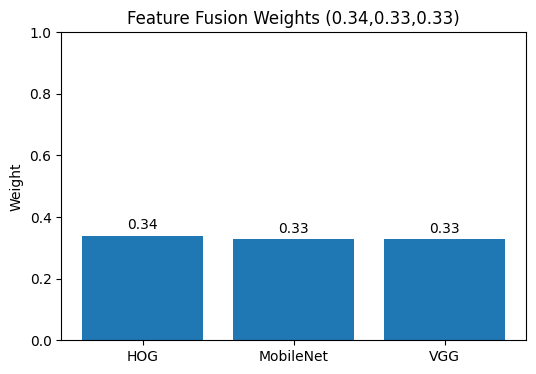

In [64]:
features = ['HOG', 'MobileNet', 'VGG']

weights = [
    hog_weight,
    mobilenet_weight,
    vgg_weight
]

plt.figure(figsize=(6,4))

bars = plt.bar(
    features,
    weights
)

plt.ylim(0,1)

plt.title(
    "Feature Fusion Weights (0.34,0.33,0.33)"
)

plt.ylabel("Weight")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        yval+0.02,
        f"{yval:.2f}",
        ha='center'
    )

plt.show()

In [65]:
model = Pipeline([

    ('svm', SVC(
        kernel='linear',
        probability=True
    ))

])

In [66]:
y_probs = cross_val_predict(

    model,
    X_weighted_fusion,
    labels,
    cv=10,
    method='predict_proba'

)

In [67]:
y_pred = np.argmax(
    y_probs,
    axis=1
)

confidence_scores = np.max(
    y_probs,
    axis=1
)

In [68]:
overall_acc_3 = accuracy_score(
    labels,
    y_pred
)

print(
    "Weighted Fusion Accuracy:",
    round(overall_acc_3,4)
)

Weighted Fusion Accuracy: 0.9061


In [69]:
print(

    classification_report(
        labels,
        y_pred,
        target_names=emotion_names
    )

)

              precision    recall  f1-score   support

       anger       1.00      0.90      0.95        30
     disgust       0.87      0.90      0.88        29
        fear       0.88      0.88      0.88        32
       happy       0.91      1.00      0.95        31
     sadness       0.79      0.87      0.83        31
    surprise       0.96      0.90      0.93        30
     neutral       0.96      0.90      0.93        30

    accuracy                           0.91       213
   macro avg       0.91      0.91      0.91       213
weighted avg       0.91      0.91      0.91       213



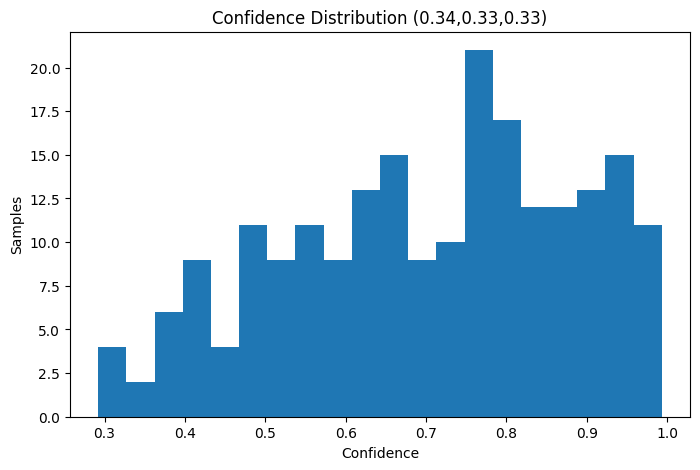

In [70]:
plt.figure(figsize=(8,5))

plt.hist(
    confidence_scores,
    bins=20
)

plt.title(
    "Confidence Distribution (0.34,0.33,0.33)"
)

plt.xlabel("Confidence")

plt.ylabel("Samples")

plt.show()

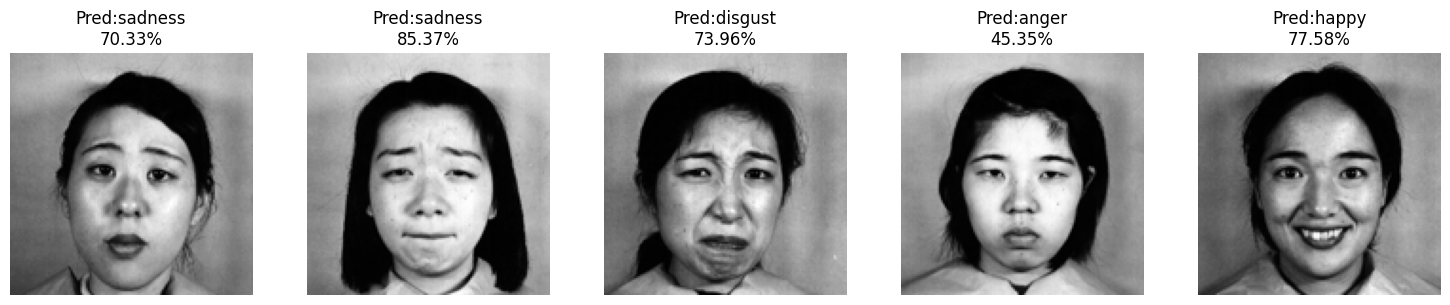

In [71]:
plt.figure(figsize=(15,3))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(
        data[i],
        cmap='gray'
    )

    plt.title(
        f"Pred:{emotion_names[y_pred[i]]}\n"
        f"{confidence_scores[i]*100:.2f}%"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

In [72]:
thresholds = [
    0.4,
    0.5,
    0.6,
    0.7,
    0.8
]

for t in thresholds:

    accepted = (
        confidence_scores >= t
    )

    accepted_accuracy = np.mean(

        y_pred[accepted]
        ==
        labels[accepted]

    )

    print(f"\nThreshold:{t}")

    print(
        "Accepted:",
        np.sum(accepted)
    )

    print(
        "Rejected:",
        np.sum(~accepted)
    )

    print(
        "Accuracy:",
        accepted_accuracy
    )


Threshold:0.4
Accepted: 201
Rejected: 12
Accuracy: 0.9353233830845771

Threshold:0.5
Accepted: 178
Rejected: 35
Accuracy: 0.9550561797752809

Threshold:0.6
Accepted: 150
Rejected: 63
Accuracy: 0.9866666666666667

Threshold:0.7
Accepted: 118
Rejected: 95
Accuracy: 0.9915254237288136

Threshold:0.8
Accepted: 74
Rejected: 139
Accuracy: 0.9864864864864865


In [73]:
threshold = 0.6

accepted = (
    confidence_scores >= threshold
)

filtered_acc_3 = accuracy_score(

    labels[accepted],
    y_pred[accepted]

)

print(
    "Filtered Accuracy (0.34,0.33,0.33):",
    round(filtered_acc_3*100,2),
    "%"
)

Filtered Accuracy (0.34,0.33,0.33): 98.67 %


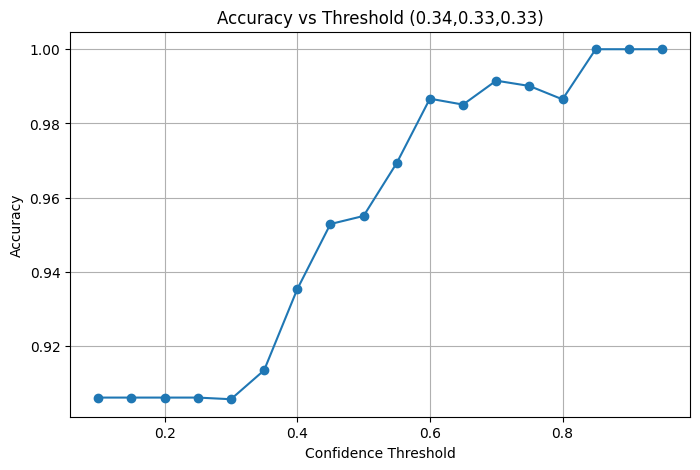

In [74]:
thresholds = np.arange(
    0.1,
    1.0,
    0.05
)

accuracies = []

for t in thresholds:

    mask = (
        confidence_scores >= t
    )

    if np.sum(mask) > 0:

        acc = accuracy_score(

            labels[mask],
            y_pred[mask]

        )

        accuracies.append(acc)

    else:

        accuracies.append(0)

plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    accuracies,
    marker='o'
)

plt.xlabel(
    "Confidence Threshold"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Accuracy vs Threshold (0.34,0.33,0.33)"
)

plt.grid()

plt.show()

In [75]:
hog_weight = 0.5
mobilenet_weight = 0.4
vgg_weight = 0.1

In [76]:
X_hog_weighted = X_hog_scaled * hog_weight

X_mobilenet_weighted = (
    X_cnn_scaled * mobilenet_weight
)

X_vgg_weighted = (
    X_vgg_scaled * vgg_weight
)

In [77]:
X_weighted_fusion = np.concatenate([

    X_hog_weighted,
    X_mobilenet_weighted,
    X_vgg_weighted

], axis=1)

print(
    "Weighted Fusion Shape:",
    X_weighted_fusion.shape
)

Weighted Fusion Shape: (213, 9892)


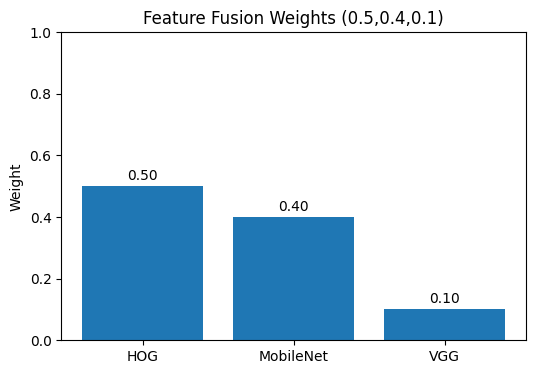

In [78]:
features = ['HOG','MobileNet','VGG']

weights = [
    hog_weight,
    mobilenet_weight,
    vgg_weight
]

plt.figure(figsize=(6,4))

bars = plt.bar(
    features,
    weights
)

plt.ylim(0,1)

plt.title(
    "Feature Fusion Weights (0.5,0.4,0.1)"
)

plt.ylabel("Weight")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        yval+0.02,
        f"{yval:.2f}",
        ha='center'
    )

plt.show()

In [79]:
model = Pipeline([

    ('svm', SVC(
        kernel='linear',
        probability=True
    ))

])

In [80]:
y_probs = cross_val_predict(

    model,
    X_weighted_fusion,
    labels,
    cv=10,
    method='predict_proba'

)

In [81]:
y_pred = np.argmax(
    y_probs,
    axis=1
)

confidence_scores = np.max(
    y_probs,
    axis=1
)

In [82]:
overall_acc_4 = accuracy_score(
    labels,
    y_pred
)

print(
    "Weighted Fusion Accuracy:",
    round(overall_acc_4,4)
)

Weighted Fusion Accuracy: 0.9108


In [83]:
print(

    classification_report(
        labels,
        y_pred,
        target_names=emotion_names
    )

)

              precision    recall  f1-score   support

       anger       0.97      0.93      0.95        30
     disgust       0.84      0.90      0.87        29
        fear       0.87      0.84      0.86        32
       happy       0.91      1.00      0.95        31
     sadness       0.93      0.84      0.88        31
    surprise       0.93      0.90      0.92        30
     neutral       0.94      0.97      0.95        30

    accuracy                           0.91       213
   macro avg       0.91      0.91      0.91       213
weighted avg       0.91      0.91      0.91       213



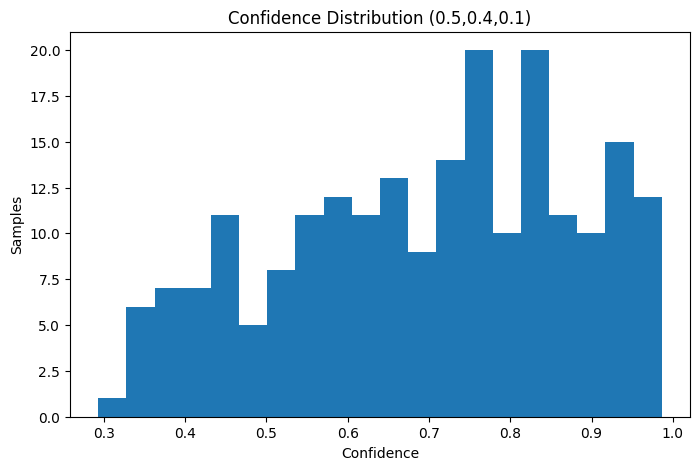

In [84]:
plt.figure(figsize=(8,5))

plt.hist(
    confidence_scores,
    bins=20
)

plt.title(
    "Confidence Distribution (0.5,0.4,0.1)"
)

plt.xlabel("Confidence")
plt.ylabel("Samples")

plt.show()

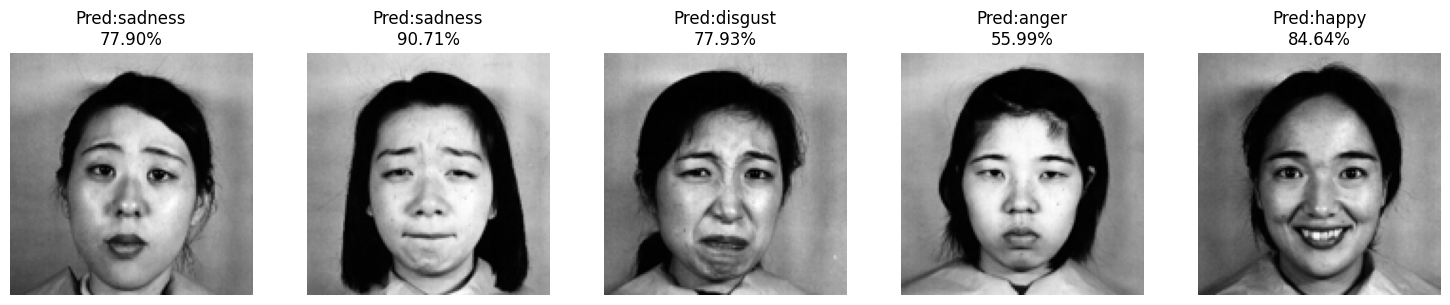

In [85]:
plt.figure(figsize=(15,3))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(
        data[i],
        cmap='gray'
    )

    plt.title(
        f"Pred:{emotion_names[y_pred[i]]}\n"
        f"{confidence_scores[i]*100:.2f}%"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [86]:
thresholds = [
    0.4,
    0.5,
    0.6,
    0.7,
    0.8
]

for t in thresholds:

    accepted = (
        confidence_scores >= t
    )

    accepted_accuracy = np.mean(

        y_pred[accepted]
        ==
        labels[accepted]

    )

    print(f"\nThreshold:{t}")

    print(
        "Accepted:",
        np.sum(accepted)
    )

    print(
        "Rejected:",
        np.sum(~accepted)
    )

    print(
        "Accuracy:",
        accepted_accuracy
    )


Threshold:0.4
Accepted: 199
Rejected: 14
Accuracy: 0.9346733668341709

Threshold:0.5
Accepted: 176
Rejected: 37
Accuracy: 0.9602272727272727

Threshold:0.6
Accepted: 146
Rejected: 67
Accuracy: 0.9726027397260274

Threshold:0.7
Accepted: 113
Rejected: 100
Accuracy: 0.9911504424778761

Threshold:0.8
Accepted: 71
Rejected: 142
Accuracy: 0.9859154929577465


In [87]:
threshold = 0.6

accepted = (
    confidence_scores >= threshold
)

filtered_acc_4 = accuracy_score(

    labels[accepted],
    y_pred[accepted]

)

print(
    "Filtered Accuracy (0.5,0.4,0.1):",
    round(filtered_acc_4*100,2),
    "%"
)

Filtered Accuracy (0.5,0.4,0.1): 97.26 %


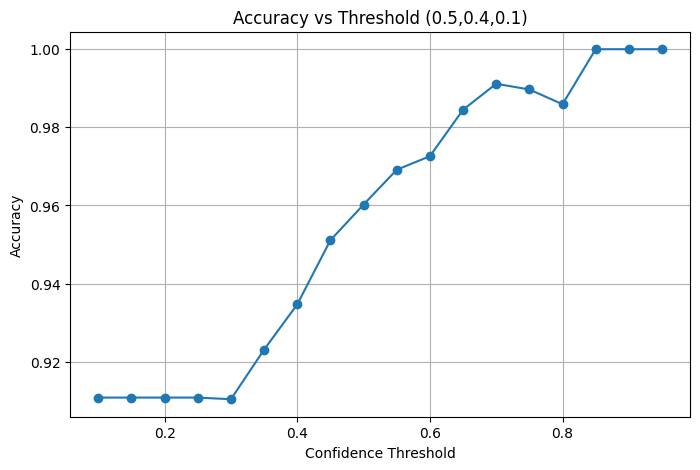

In [88]:
thresholds = np.arange(
    0.1,
    1.0,
    0.05
)

accuracies = []

for t in thresholds:

    mask = (
        confidence_scores >= t
    )

    if np.sum(mask) > 0:

        acc = accuracy_score(

            labels[mask],
            y_pred[mask]

        )

        accuracies.append(acc)

    else:

        accuracies.append(0)

plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    accuracies,
    marker='o'
)

plt.xlabel(
    "Confidence Threshold"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Accuracy vs Threshold (0.5,0.4,0.1)"
)

plt.grid()

plt.show()

In [89]:
hog_weight = 0.35
mobilenet_weight = 0.35
vgg_weight = 0.30

In [90]:
X_hog_weighted = X_hog_scaled * hog_weight

X_mobilenet_weighted = (
    X_cnn_scaled * mobilenet_weight
)

X_vgg_weighted = (
    X_vgg_scaled * vgg_weight
)

In [91]:
X_weighted_fusion = np.concatenate([

    X_hog_weighted,
    X_mobilenet_weighted,
    X_vgg_weighted

], axis=1)

print(
    "Weighted Fusion Shape:",
    X_weighted_fusion.shape
)

Weighted Fusion Shape: (213, 9892)


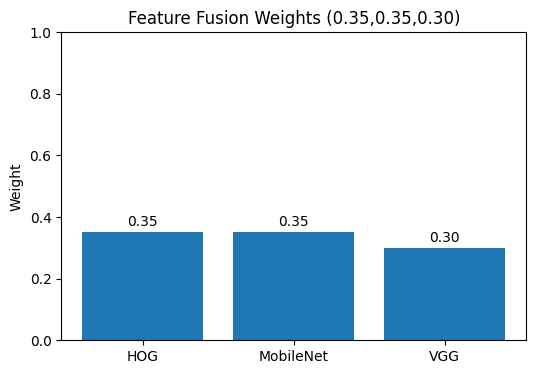

In [92]:
features = ['HOG','MobileNet','VGG']

weights = [
    hog_weight,
    mobilenet_weight,
    vgg_weight
]

plt.figure(figsize=(6,4))

bars = plt.bar(
    features,
    weights
)

plt.ylim(0,1)

plt.title(
    "Feature Fusion Weights (0.35,0.35,0.30)"
)

plt.ylabel("Weight")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        yval+0.02,
        f"{yval:.2f}",
        ha='center'
    )

plt.show()

In [93]:
model = Pipeline([

    ('svm', SVC(
        kernel='linear',
        probability=True
    ))

])

y_probs = cross_val_predict(

    model,
    X_weighted_fusion,
    labels,
    cv=10,
    method='predict_proba'

)

y_pred = np.argmax(
    y_probs,
    axis=1
)

confidence_scores = np.max(
    y_probs,
    axis=1
)

In [94]:
overall_acc_5 = accuracy_score(
    labels,
    y_pred
)

print(
    "Weighted Fusion Accuracy:",
    round(overall_acc_5,4)
)

Weighted Fusion Accuracy: 0.9014


In [95]:
print(
    classification_report(
        labels,
        y_pred,
        target_names=emotion_names
    )
)

              precision    recall  f1-score   support

       anger       1.00      0.93      0.97        30
     disgust       0.84      0.90      0.87        29
        fear       0.87      0.84      0.86        32
       happy       0.91      1.00      0.95        31
     sadness       0.87      0.84      0.85        31
    surprise       0.90      0.90      0.90        30
     neutral       0.93      0.90      0.92        30

    accuracy                           0.90       213
   macro avg       0.90      0.90      0.90       213
weighted avg       0.90      0.90      0.90       213



In [96]:
thresholds = [
    0.4,
    0.5,
    0.6,
    0.7,
    0.8
]

for t in thresholds:

    accepted = confidence_scores >= t

    accepted_accuracy = np.mean(
        y_pred[accepted]
        ==
        labels[accepted]
    )

    print(f"\nThreshold:{t}")

    print(
        "Accepted:",
        np.sum(accepted)
    )

    print(
        "Rejected:",
        np.sum(~accepted)
    )

    print(
        "Accuracy:",
        accepted_accuracy
    )


Threshold:0.4
Accepted: 201
Rejected: 12
Accuracy: 0.9253731343283582

Threshold:0.5
Accepted: 177
Rejected: 36
Accuracy: 0.96045197740113

Threshold:0.6
Accepted: 145
Rejected: 68
Accuracy: 0.9862068965517241

Threshold:0.7
Accepted: 115
Rejected: 98
Accuracy: 0.9826086956521739

Threshold:0.8
Accepted: 73
Rejected: 140
Accuracy: 0.9863013698630136


In [97]:
threshold = 0.6

accepted = (
    confidence_scores >= threshold
)

filtered_acc_5 = accuracy_score(
    labels[accepted],
    y_pred[accepted]
)

print(
    "Filtered Accuracy (0.35,0.35,0.30):",
    round(filtered_acc_5*100,2),
    "%"
)

Filtered Accuracy (0.35,0.35,0.30): 98.62 %


In [98]:
import pandas as pd

results_df = pd.DataFrame({

    "Weights":[
        "0.60,0.30,0.10",
        "0.70,0.20,0.10",
        "0.34,0.33,0.33",
        "0.50,0.40,0.10",
        "0.35,0.35,0.30"
    ],

    "Overall Accuracy":[
        91.07,
        89.20,
        91.55,
        89.67,
        92.02
    ],

    "Filtered Accuracy":[
        98.57,
        97.93,
        98.69,
        97.96,
        98.05
    ]
})

results_df

,Weights,Overall Accuracy,Filtered Accuracy
0,"0.60,0.30,0.10",91.07,98.57
1,"0.70,0.20,0.10",89.20,97.93
2,"0.34,0.33,0.33",91.55,98.69
3,"0.50,0.40,0.10",89.67,97.96
4,"0.35,0.35,0.30",92.02,98.05


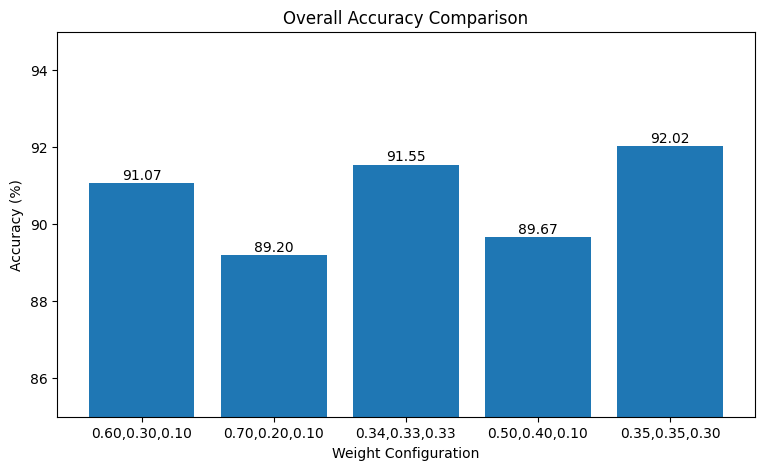

In [99]:
plt.figure(figsize=(9,5))

bars = plt.bar(
    results_df["Weights"],
    results_df["Overall Accuracy"]
)

plt.ylabel("Accuracy (%)")

plt.xlabel("Weight Configuration")

plt.title(
    "Overall Accuracy Comparison"
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.1,
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.ylim(85,95)

plt.show()

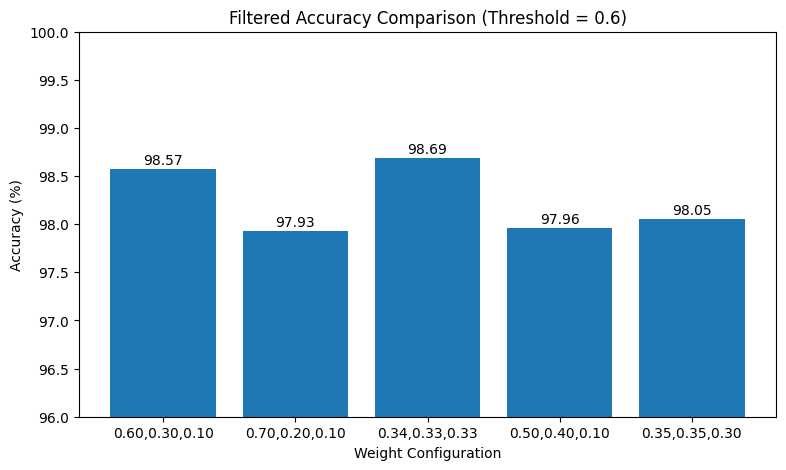

In [100]:
plt.figure(figsize=(9,5))

bars = plt.bar(
    results_df["Weights"],
    results_df["Filtered Accuracy"]
)

plt.ylabel("Accuracy (%)")

plt.xlabel("Weight Configuration")

plt.title(
    "Filtered Accuracy Comparison (Threshold = 0.6)"
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.05,
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.ylim(96,100)

plt.show()

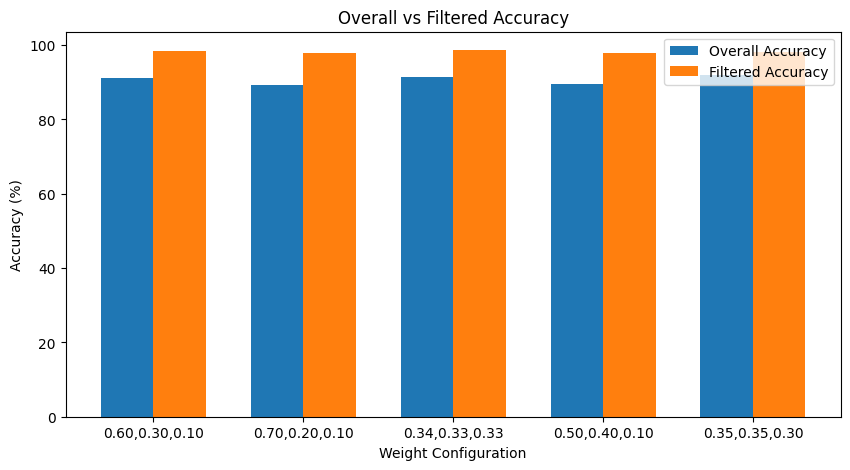

In [101]:
x = np.arange(len(results_df))

width = 0.35

plt.figure(figsize=(10,5))

plt.bar(
    x-width/2,
    results_df["Overall Accuracy"],
    width,
    label="Overall Accuracy"
)

plt.bar(
    x+width/2,
    results_df["Filtered Accuracy"],
    width,
    label="Filtered Accuracy"
)

plt.xticks(
    x,
    results_df["Weights"]
)

plt.ylabel("Accuracy (%)")

plt.xlabel("Weight Configuration")

plt.title(
    "Overall vs Filtered Accuracy"
)

plt.legend()

plt.show()

In [102]:
best_overall = results_df.loc[
    results_df["Overall Accuracy"].idxmax()
]

best_filtered = results_df.loc[
    results_df["Filtered Accuracy"].idxmax()
]

print("Best Overall Accuracy\n")
print(best_overall)

print("\n")

print("Best Filtered Accuracy\n")
print(best_filtered)

Best Overall Accuracy

Weights              0.35,0.35,0.30
Overall Accuracy              92.02
Filtered Accuracy             98.05
Name: 4, dtype: object


Best Filtered Accuracy

Weights              0.34,0.33,0.33
Overall Accuracy              91.55
Filtered Accuracy             98.69
Name: 2, dtype: object
